In [2]:
# import the libraries
import numpy as np
import pandas as pd


In [3]:
# loading the dataset
data = pd.read_csv("C:\\Users\\Lenovo\\Downloads\\loan_sanction_test (1).csv")


In [4]:
# Display the first few rows of the dataset to understand its structure.

data.head(7)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
5,LP001054,Male,Yes,0,Not Graduate,Yes,2165,3422,152.0,360.0,1.0,Urban
6,LP001055,Female,No,1,Not Graduate,No,2226,0,59.0,360.0,1.0,Semiurban


In [5]:

# Check for missing values and handle them if necessary.

data.isna().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [6]:
# to know about the short summary of entire dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [7]:
data['Gender'].mode()[0]

'Male'

In [8]:
# Check for missing values and handle them if necessary. 

In [9]:
data['Gender'] = data['Gender'].fillna(value=data['Gender'].mode()[0])


In [10]:
categorical_cols = data.select_dtypes(exclude="number")[['Dependents', 'Self_Employed']].columns.tolist()
categorical_cols


['Dependents', 'Self_Employed']

In [11]:
 data.select_dtypes(exclude="number").isna().sum()

Loan_ID           0
Gender            0
Married           0
Dependents       10
Education         0
Self_Employed    23
Property_Area     0
dtype: int64

In [12]:
for col in categorical_cols:
    data[col] = data[col].fillna(value=data[col].mode()[0])
    

In [13]:
 data.select_dtypes(exclude="number").isna().sum()

Loan_ID          0
Gender           0
Married          0
Dependents       0
Education        0
Self_Employed    0
Property_Area    0
dtype: int64

In [14]:
numerical_cols = data.select_dtypes(include="number").columns.tolist()
numerical_cols

['ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History']

In [15]:
# to check the null values in numerical cols
data.select_dtypes(include="number").isna().sum()

ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
dtype: int64

In [16]:
for col in numerical_cols:
    data[col] = data[col].fillna(value=data[col].median())
    

In [17]:
data.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

this data is cleaned successfully! -> null values are totally eliminated !

now, we can move ahead with next step of analysis!

##### 3. Summarize basic statistics (mean, median, standard deviation, etc.) for the numeric columns

In [18]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,367.000000,367.000000,367.000000
mean,4805.599455,1569.577657,135.980926,342.822888,0.839237
std,4910.685399,2334.232099,60.959739,64.658402,0.367814
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,101.000000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,157.500000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


## Analysis

#### 2.1 Univariate Analysis

###### 1. Histograms: Plot the frequency distribution of key numeric variables

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns


In [20]:
numerical_cols

['ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History']

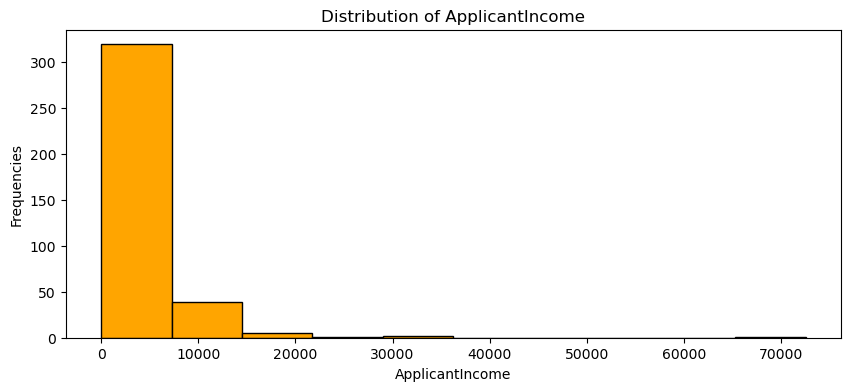

In [21]:
# histogram
plt.figure(figsize=(10,4))
plt.hist(data['ApplicantIncome'], color='orange', edgecolor="black")
plt.xlabel("ApplicantIncome")
plt.ylabel("Frequencies")
plt.title("Distribution of ApplicantIncome")
plt.show()

#### insight:

the chart says that the most of people who applied for the loan, have incomes in between 10 to 10000 Rs.

and, rest cases are rarest or, outliers (exceptional cases).


In [22]:
from scipy.stats import skew
skew(data['ApplicantIncome'])

np.float64(8.40683417612701)

In [23]:
# for col in numerical_cols:

#     plt.figure(figsize=(10,4))
#     plt.hist(data[col], color='orange', edgecolor="black")
#     plt.xlabel(col)
#     plt.ylabel("Frequencies")
#     plt.title(f"Distribution of {col}")
#     plt.show()
#     print("-"*120)

##### insight of every chart:




##### 2. Box Plots: Identify potential outliers and visualize the spread of data

Text(0.5, 1.0, 'Spread of Incomes of People')

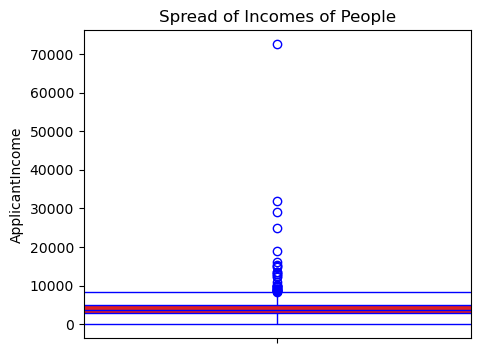

In [24]:
plt.figure(figsize=(5, 4))
sns.boxplot(data['ApplicantIncome'], color="red", gap=40, linecolor="blue", linewidth=1)
plt.title("Spread of Incomes of People")

##### Insight:

there is only 1 person, with income above Rs. 72,000 who applied for the Loan, and most of the people who applied for the loan are presnet in the bracket of 5000 to 12,000

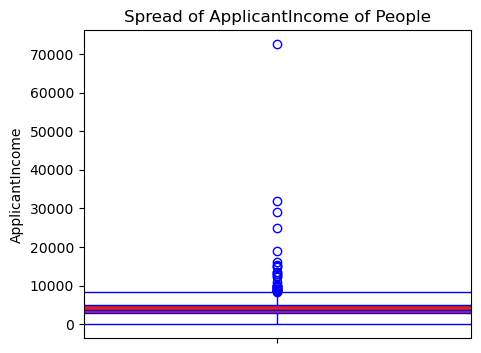

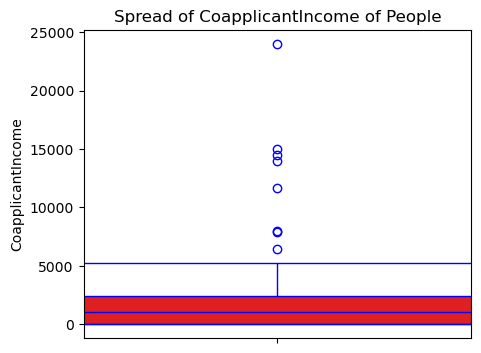

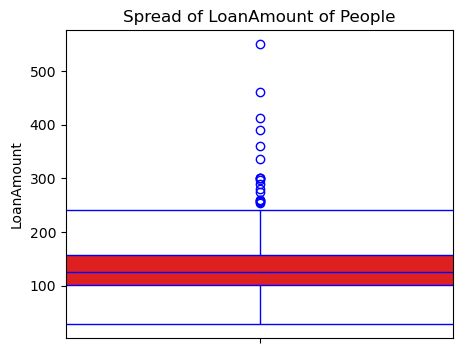

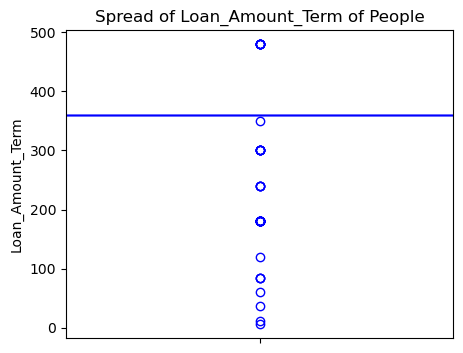

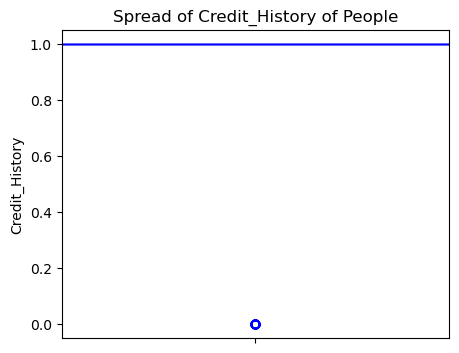

In [25]:
for col in numerical_cols:
    plt.figure(figsize=(5, 4))
    sns.boxplot(data[col], color="red", gap=40, linecolor="blue", linewidth=1)
    plt.title(f"Spread of {col} of People")

    

##### insight:



distribution  -> frequencies!

x-axis -> data/values
y-axis -> counts

numericals -> histogram -> continuous values!
categorical -> bar charts!


##### 3. Bar Charts: Visualize the frequency distribution of categorical variables

In [26]:
categorical_cols = data.select_dtypes(include="object").columns.tolist()
categorical_cols

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area']

In [27]:
result = data.groupby("Gender").agg(Counts=("Loan_ID", "count")).reset_index()
# result

result['totals'] = result.apply(lambda x: x.iloc[1], axis=1).sum()

result['pct_contbr'] = result.apply(lambda x: round((x[1]/x[2]), 2)*100, axis=1)

result

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15880\2838038022.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  result['pct_contbr'] = result.apply(lambda x: round((x[1]/x[2]), 2)*100, axis=1)


,Gender,Counts,totals,pct_contbr
0,Female,70,367,19.0
1,Male,297,367,81.0


[Text(0, 0, '70'), Text(0, 0, '297')]

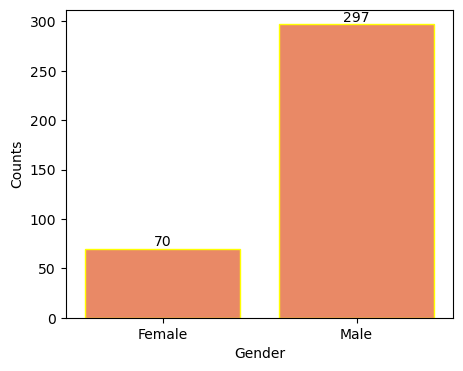

In [28]:
plt.figure(figsize=(5, 4))
ax = sns.barplot(x=result['Gender'], y=result['Counts'], edgecolor="yellow", color="coral" )

ax.bar_label(ax.containers[0]) #


#### insight:

The people who applied for the loan are mostly 'Males' with number around 297, which makes ***around 81%*** of overall applications in loans.

In [29]:
categorical_cols.remove("Loan_ID")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15880\2973078940.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  result['pct_contbr'] = result.apply(lambda x: round((x[1]/x[2]), 2)*100, axis=1)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15880\2973078940.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  result['pct_contbr'] = result.apply(lambda x: round((x[1]/x[2]), 2)*100, axis=1)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15880\2973078940.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFr

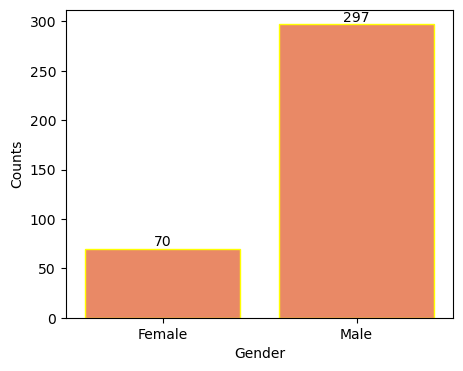

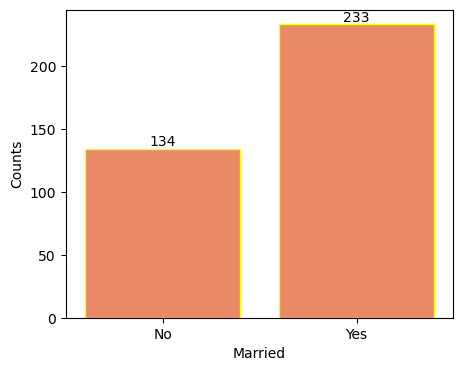

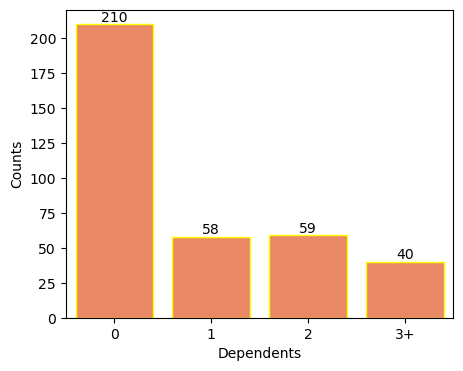

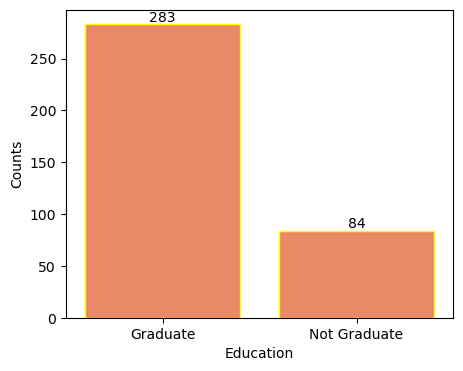

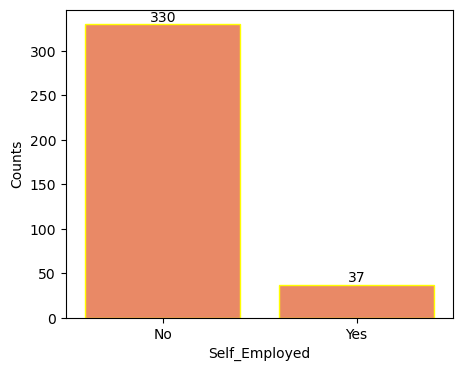

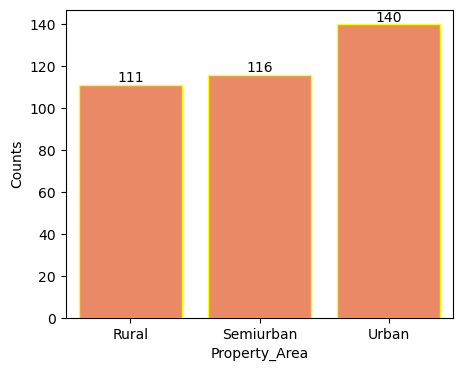

In [30]:
for col in categorical_cols:
    result = data.groupby(col).agg(Counts=("Loan_ID", "count")).reset_index()

    result['totals'] = result.apply(lambda x: x.iloc[1], axis=1).sum()

    result['pct_contbr'] = result.apply(lambda x: round((x[1]/x[2]), 2)*100, axis=1)

    # print(result)
    
    plt.figure(figsize=(5, 4))
    ax = sns.barplot(x=result[col], y=result['Counts'], edgecolor="yellow", color="coral" )

    ax.bar_label(ax.containers[0]) #


#### 4. Pie Charts: Represent the composition of categorical variables

In [31]:
result = data.groupby("Gender").size().reset_index().rename(columns={0:'Counts'})
result

,Gender,Counts
0,Female,70
1,Male,297


([<matplotlib.patches.Wedge at 0x20d57edb770>,
 [Text(0.9083571489611347, 0.6203928512895671, 'Female'),
  Text(-0.9083571317029622, -0.6203928765583689, 'Male')],
 [Text(0.49546753579698255, 0.3383961007034002, '19.1%'),
  Text(-0.49546752638343383, -0.338396114486383, '80.9%')])

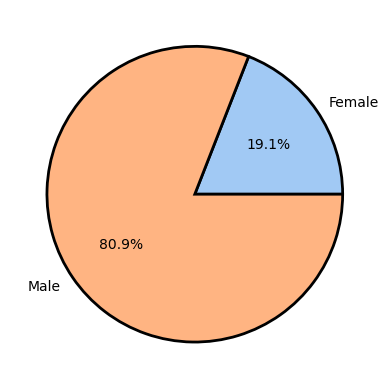

In [32]:
sns.set_palette("pastel")

plt.pie(x=result['Counts'], labels=result['Gender'], autopct="%1.1f%%",
       
       # --- Custom Border/Edge Settings ---
    wedgeprops={"edgecolor": "black", 'linewidth': 2, 'antialiased': True}   )


Insight from your pie chart (Gender Distribution):

Male applicants dominate → 80.9% of the dataset are male.

Female applicants are fewer → only 19.1% of the dataset.

This imbalance suggests that loan applications are heavily skewed towards males.

## Bivariate Analysis

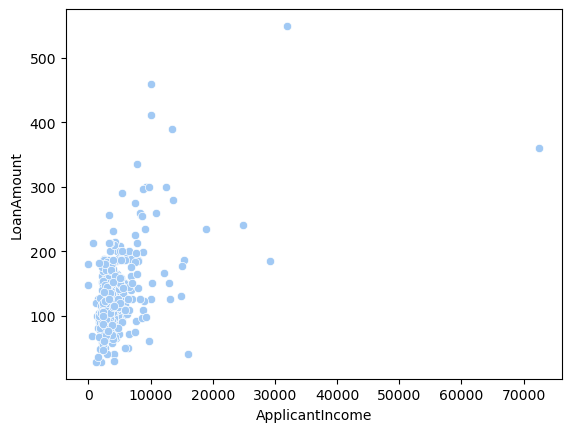

In [33]:
sns.scatterplot(x=data['ApplicantIncome'], y=data['LoanAmount'])
plt.show()

Short Insight (ApplicantIncome vs LoanAmount scatter plot):

Most applicants → income < 20,000 and loan amount < 300.

Few outliers → very high income + high loan amount.

Trend → loan amount generally increases with income, but relation is weak (exceptions exist).

👉 Simple line: Income ↑ → loan ↑ (mostly), but not always.



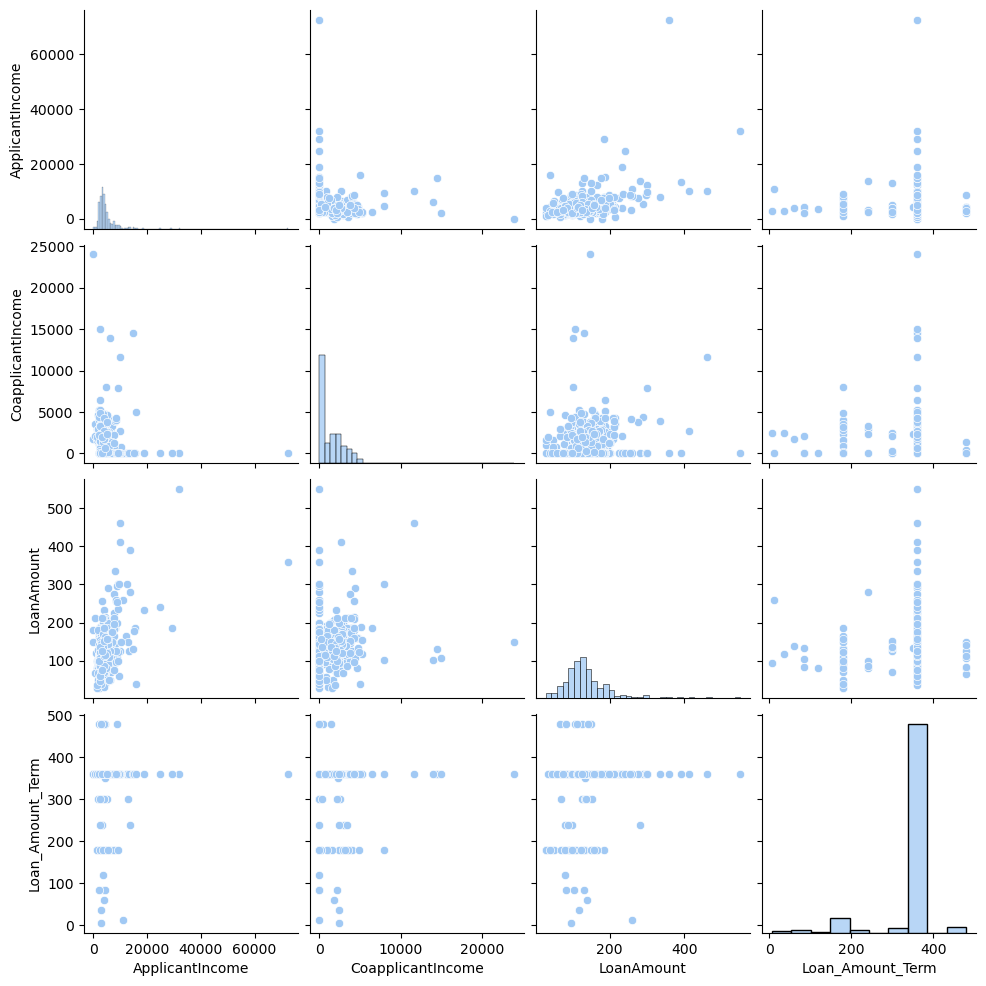

In [34]:
sns.pairplot(data[['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']])
plt.show()

Pair Plot Insight (ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term)

ApplicantIncome vs LoanAmount → Clear moderate positive trend. Higher applicant incomes generally link to larger loan amounts.

CoapplicantIncome vs LoanAmount → Weak relationship. Co‑applicant income doesn’t strongly influence loan size.

ApplicantIncome vs CoapplicantIncome → Slight negative tendency, suggesting higher earning applicants often apply without strong co‑applicant support.

Loan_Amount_Term vs others → Very weak or no correlation. Loan term length is largely independent of income or loan size.

Histograms (diagonal) → Show skewed distributions: ApplicantIncome and LoanAmount are concentrated at lower values, with a few extreme outliers.

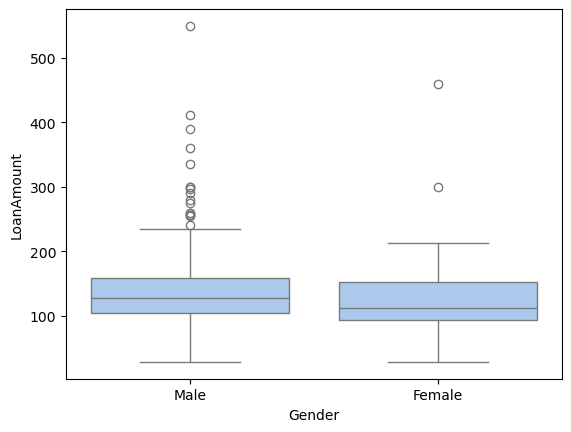

In [35]:
sns.boxplot(x=data['Gender'], y=data['LoanAmount'])
plt.show()


nsight (Box Plot: LoanAmount by Gender)

Median loan amount → Slightly higher for Male applicants compared to Female.

Spread (IQR) → Both genders show similar ranges of loan amounts.

Outliers → Males have more extreme high loan cases (some >500), while females have fewer and less extreme outliers.

## Multivariate Analysis

In [36]:
corr = data[['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']].corr()
print(corr)


                   ApplicantIncome  CoapplicantIncome  LoanAmount  \
ApplicantIncome           1.000000          -0.110335    0.488737   
CoapplicantIncome        -0.110335           1.000000    0.150034   
LoanAmount                0.488737           0.150034    1.000000   
Loan_Amount_Term          0.023319          -0.008633    0.091867   

                   Loan_Amount_Term  
ApplicantIncome            0.023319  
CoapplicantIncome         -0.008633  
LoanAmount                 0.091867  
Loan_Amount_Term           1.000000  


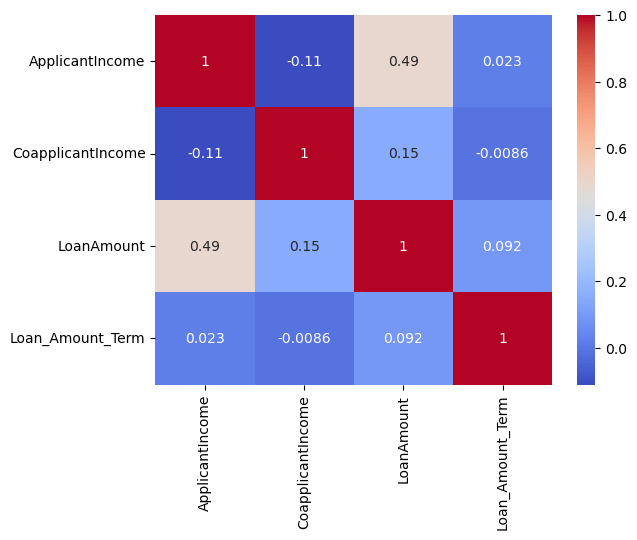

In [37]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

📊 Heatmap Insight (Correlation Matrix)

ApplicantIncome vs LoanAmount → 0.49 → Moderate positive correlation. Higher income applicants generally request larger loans.

CoapplicantIncome vs LoanAmount → 0.15 → Weak positive correlation. Co‑applicant income has little effect on loan size.

ApplicantIncome vs CoapplicantIncome → -0.11 → Slight negative correlation, meaning applicants with higher income often have lower co‑applicant income (possibly single earners).

Loan_Amount_Term vs others → very weak correlations (near 0)

<Axes: xlabel='Gender', ylabel='ApplicantIncome'>

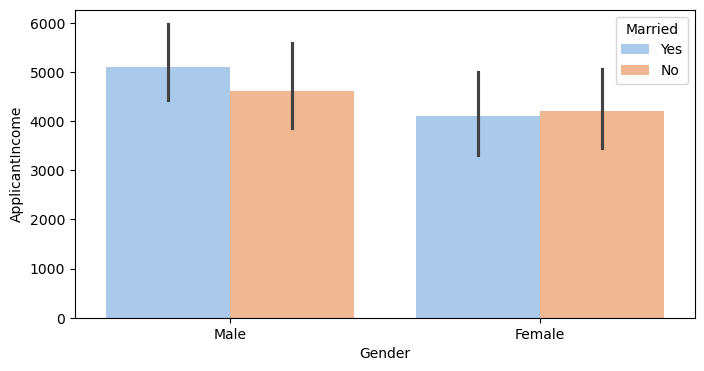

In [38]:
plt.figure(figsize=(8, 4))
sns.barplot(x=data['Gender'], y=data['ApplicantIncome'], hue=data['Married'] )

Insight (Bar Chart: Gender, Marital Status, and Applicant Income)

Male applicants → Married males show higher average income compared to unmarried males.

Female applicants → Income difference between married and unmarried females is minimal, with unmarried females slightly higher.

Variability → Error bars suggest more spread in male incomes, while female incomes are relatively consistent.

## Final Conclusion

***The analysis shows that ApplicantIncome is the strongest factor influencing LoanAmount, while CoapplicantIncome and LoanTerm have weak impact.
Gender differences are minimal, though males show more extreme loan outliers.
Property_Area and Marital Status reveal important socioeconomic patterns, with urban applicants and married males showing higher approvals and incomes.
Overall, loan approvals are shaped mainly by income and property area, with other variables playing a minor role.***